In [ ]:
# REFERENCE:
#   - Annotated Diffusion, Niels Rogge and Kashif Rasul (other ref inside here, nicely detailed)
#     https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/annotated_diffusion.ipynb#scrollTo=51d9a24c

import math
from inspect import isfunction
from functools import partial
from typing import Any, Callable

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.types import Tensor

import stardust as sd

### **Notes**

- original DDPM approach with fixed learned variance (see [Improved DDPM](https://proceedings.mlr.press/v139/nichol21a/nichol21a.pdf) for optimised var during network training).

### **Network Setup**

In [16]:
def set_default(val: Any, d: Any) -> Any:
    """Returns given obj (if exists), else a default value."""
    if val is not None:
        return val
    return d() if isfunction(d) else d

In [17]:
class ResidualConnection(nn.Module):
    """
    Defines a residual connection for a network by adding the
    given input obj to the output of a particular function.
    """
    def __init__(self, fn: Callable[[Tensor, Any], Tensor]) -> None:
        super().__init__()
        self.fn = fn

    def forward(self, x: Tensor, *args, **kwargs) -> Tensor:
        return self.fn(x, *args, **kwargs) + x


def Downsample(chs: int) -> Callable[[Tensor], Tensor]:
    """Defines a downsampling op through `nn.Conv2d` obj."""
    return nn.Conv2d(chs, chs, 4, 2, 1)

def Upsample(chs: int) -> Callable[[Tensor], Tensor]:
    """Defines an upsampling op through `nn.ConvTranspose2d` obj."""
    return nn.ConvTranspose2d(chs, chs, 4, 2, 1)

In [18]:
class SinusoidalPositionEmbeddings(nn.Module):
    """Defines Sinusoidal position embedding to encode the batch noise time step."""
    def __init__(self, dim: int) -> None:
        super().__init__()
        self.dim = dim
    
    def forward(self, time: Tensor) -> Tensor:
        device = time.device
        half_dim = self.dim // 2

        c = math.log(1e4) / (half_dim - 1)
        exps = torch.exp(-c * torch.arange(half_dim, device=device))
        emb = time[:, None] * exps[None, :]

        embeddings = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return embeddings

In [19]:
class Block(nn.Module):
    """Block architecture."""
    def __init__(self, dim: int, dim_out: int, groups: int = 8) -> None:
        super().__init__()
        self.conv = nn.Conv2d(dim, dim_out, 3, padding = 1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()

    def forward(self, x, scale_shift = None):
        x = self.conv(x)
        x = self.norm(x)

        if scale_shift is not None:
            scale, shift = scale_shift
            x = (scale + 1) * x + shift

        x = self.act(x)
        return x

class ResnetBlock(nn.Module):
    """Residual block from: https://arxiv.org/abs/1512.03385"""
    def __init__(
        self,
        dim: int,
        dim_out: int,
        *,
        time_emb_dim: int | None = None,
        groups: int = 8
    ) -> None:
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, dim_out))
            if time_emb_dim is not None
            else None
        )
        self.block1 = Block(dim, dim_out, groups=groups)
        self.block2 = Block(dim_out, dim_out, groups=groups)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x: Tensor, time_emb: Tensor | None = None) -> Tensor:
        h = self.block1(x)
        if all(map(lambda x: x is not None, (self.mlp, time_emb))):
            condition = self.mlp(time_emb)
            h += condition[..., None, None]
        h = self.block2(h)
        return h + self.res_conv(x)
    
class ConvNextBlock(nn.Module):
    """Residual block from: https://arxiv.org/abs/2201.03545"""
    def __init__(
        self,
        dim: int,
        dim_out: int,
        *,
        time_emb_dim: int | None = None,
        mult: int = 2,
        norm: bool = True
    ) -> None:
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.GELU(), nn.Linear(time_emb_dim, dim))
            if time_emb_dim is not None
            else None
        )
        self.ds_conv = nn.Conv2d(dim, dim, 7, padding=3, groups=dim)
        self.net = nn.Sequential(
            nn.GroupNorm(1, dim) if norm else nn.Identity(),
            nn.Conv2d(dim, dim_out * mult, 3, padding=1),
            nn.GELU(),
            nn.GroupNorm(1, dim_out * mult),
            nn.Conv2d(dim_out * mult, dim_out, 3, padding=1),
        )
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x: Tensor, time_emb: Tensor | None = None) -> Tensor:
        h = self.ds_conv(x)
        if all(map(lambda x: x is not None, (self.mlp, time_emb))):
            condition = self.mlp(time_emb)
            h += condition[..., None, None]
        h = self.net(h)
        return h + self.res_conv(x)

In [20]:
class Attention(nn.Module):
    """Regular multi-head self-attention module."""
    def __init__(self, dim: int, heads: int = 4, dim_head: int = 32) -> None:
        super().__init__()
        self.scale = pow(dim_head, -0.5)
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x: Tensor) -> Tensor:
        b, _, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: t.view(b, self.heads, -1, h * w), 
            qkv
        )
        q = q * self.scale
        sim = torch.matmul(q.transpose(-1, -2), k) 
        sim = sim - sim.amax(dim=-1, keepdim=True).detach()
        attn = sim.softmax(dim=-1)
        out = torch.matmul(attn, v.transpose(-1, -2))
        out = out.transpose(-1, -2).reshape(b, -1, h, w)
        return self.to_out(out)


class LinearAttention(nn.Module):
    """Linear attention module variant (time- and memory costs are `O(sequence length)`)."""
    def __init__(self, dim: int, heads: int = 4, dim_head: int = 32) -> None:
        super().__init__()
        self.scale = pow(dim_head, -0.5)
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Sequential(
            nn.Conv2d(hidden_dim, dim, 1), 
            nn.GroupNorm(1, dim)
        )

    def forward(self, x: Tensor) -> Tensor:
        b, _, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: t.view(b, self.heads, -1, h * w), 
            qkv
        )
        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)
        q = q * self.scale
        context = torch.matmul(k, v.transpose(-1, -2))
        out = torch.matmul(context.transpose(-1, -2), q)
        out = out.reshape(b, -1, h, w)
        return self.to_out(out)

In [21]:
# NOTE: Group normalization (from the NB)
#   - The DDPM authors interleave the convolutional/attention layers of the U-Net with group normalization (Wu et al., 2018).
#   - Below, we define a PreNorm class, which will be used to apply groupnorm before the attention layer, as we'll see further.
#   - Note that there's been a debate about whether to apply normalization before or after attention in Transformers.

class PreNorm(nn.Module):
    def __init__(self, dim: int, fn: Callable) -> None:
        super().__init__()
        self.fn = fn
        self.norm = nn.GroupNorm(1, dim)

    def forward(self, x: Tensor) -> Tensor:
        x = self.norm(x)
        return self.fn(x)

### **Conditional U-Net Architecture**

Now that we've defined all building blocks (position embeddings, ResNet/ConvNeXT blocks, attention and group normalization), it's time to define the entire neural network. Recall that the job of the network $\mathbf{\epsilon}_\theta(\mathbf{x}_t, t)$ is to take in a batch of noisy images + noise levels, and output the noise added to the input. More formally:

- the network takes a batch of noisy images of shape `(batch_size, num_channels, height, width)` and a batch of noise levels of shape `(batch_size, 1)` as input, and returns a tensor of shape `(batch_size, num_channels, height, width)`

The network is built up as follows:
* first, a convolutional layer is applied on the batch of noisy images, and position embeddings are computed for the noise levels
* next, a sequence of downsampling stages are applied. Each downsampling stage consists of 2 ResNet/ConvNeXT blocks + groupnorm + attention + residual connection + a downsample operation
* at the middle of the network, again ResNet or ConvNeXT blocks are applied, interleaved with attention
* next, a sequence of upsampling stages are applied. Each upsampling stage consists of 2 ResNet/ConvNeXT blocks + groupnorm + attention + residual connection + an upsample operation
* finally, a ResNet/ConvNeXT block followed by a convolutional layer is applied.

In [22]:
class Unet(nn.Module):
    """Conditional U-Net implementation, with group pre-norm and linear attention."""
    def __init__(
        self,
        dim: int,
        init_dim: int | None = None,
        out_dim: int | None = None,
        dim_mults: tuple[int, ...] = (1, 2, 4, 8),
        channels: int | None = 3,
        with_time_emb: bool = True,
        use_convnext: bool = True,
        convnext_mult: int | None = 2,
        resnet_block_groups: int | None = 8,
    ) -> None:
        super().__init__()
        # determine dimensions
        self.channels = channels

        init_dim = set_default(init_dim, 2 * dim // 3)
        self.init_conv = nn.Conv2d(channels, init_dim, 7, padding=3)

        dims = [init_dim, *map(lambda m: dim * m, dim_mults)]
        in_out = list(zip(dims[:-1], dims[1:]))
        
        if use_convnext:
            block_klass = partial(ConvNextBlock, mult=convnext_mult)
        else:
            block_klass = partial(ResnetBlock, groups=resnet_block_groups)
        
        # time embeddings
        if with_time_emb:
            time_dim = dim * 4
            self.time_mlp = nn.Sequential(
                SinusoidalPositionEmbeddings(dim),
                nn.Linear(dim, time_dim),
                nn.GELU(),
                nn.Linear(time_dim, time_dim),
            )
        else:
            time_dim = None
            self.time_mlp = None
        
        # layers
        self.downs = nn.ModuleList([])
        self.ups = nn.ModuleList([])
        num_resolutions = len(in_out)

        for ind, (dim_in, dim_out) in enumerate(in_out):
            is_last = ind >= (num_resolutions - 1)
            self.downs.append(
                nn.ModuleList(
                    [
                        block_klass(dim_in, dim_out, time_emb_dim=time_dim),
                        block_klass(dim_out, dim_out, time_emb_dim=time_dim),
                        ResidualConnection(PreNorm(dim_out, LinearAttention(dim_out))),
                        Downsample(dim_out) if not is_last else nn.Identity(),
                    ]
                )
            )

        mid_dim = dims[-1]
        self.mid_block1 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim)
        self.mid_attn = ResidualConnection(PreNorm(mid_dim, Attention(mid_dim)))
        self.mid_block2 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim)

        for ind, (dim_in, dim_out) in enumerate(reversed(in_out[1:])):
            is_last = ind >= (num_resolutions - 1)
            self.ups.append(
                nn.ModuleList(
                    [
                        block_klass(dim_out * 2, dim_in, time_emb_dim=time_dim),
                        block_klass(dim_in, dim_in, time_emb_dim=time_dim),
                        ResidualConnection(PreNorm(dim_in, LinearAttention(dim_in))),
                        Upsample(dim_in) if not is_last else nn.Identity(),
                    ]
                )
            )

        out_dim = set_default(out_dim, channels)
        self.final_conv = nn.Sequential(
            block_klass(dim, dim), nn.Conv2d(dim, out_dim, 1),
        )


    def forward(self, x: Tensor, time: Tensor) -> Tensor:
        x = self.init_conv(x)
        t = self.time_mlp(time) if self.time_mlp is not None else None
        h = []

        # downsample
        for block1, block2, attn, downsample in self.downs:
            x = block1(x, t)
            x = block2(x, t)
            x = attn(x)
            h.append(x)
            x = downsample(x)

        # bottleneck
        x = self.mid_block1(x, t)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t)

        # upsample
        for block1, block2, attn, upsample in self.ups:
            x = torch.cat((x, h.pop()), dim=1)
            x = block1(x, t)
            x = block2(x, t)
            x = attn(x)
            x = upsample(x)

        return self.final_conv(x)

### **Define the Forward Diffusion Process**

The forward diffusion process gradually adds noise to an image from the real distribution, in a number of time steps $T$. This happens according to a **variance schedule**. The original DDPM authors employed a linear schedule:

* We set the forward process variances to constants increasing linearly from $\beta_1 = 10^{−4}$ to $\beta_T = 0.02$.

However, it was shown in ([Nichol et al., 2021](https://arxiv.org/abs/2102.09672)) that better results can be achieved when employing a cosine schedule.

Below, we define various schedules for the $T$ timesteps, as well as corresponding variables which we'll need, such as cumulative variances.

In [ ]:
from stardust.diffusion import Sampler

beta_start = 1e-4
beta_end = 2e-2
TIMESTEPS = 200

# define beta schedule
scheduler = sd.NoiseScheduler(TIMESTEPS)
BETAS = scheduler.linear(beta_start, beta_end)

# define diffusion process
# DIFFUSER = sd.Diffuser(BETAS)
sampler: Sampler = Sampler(BETAS)

In [24]:
# loss
def p_losses(
    denoise_model: nn.Module,
    sampler: Sampler,
    x_start: Tensor,
    t: Tensor,
    noise: Tensor | None = None,
    loss_type: str = 'l1'
):
    if noise is None:
        noise = torch.randn_like(x_start)

    x_noisy = sampler.q_sample(x=x_start, t=t, noise=noise)
    predicted_noise = denoise_model(x_noisy, t)

    match loss_type:
        case 'l1': loss = F.l1_loss(noise, predicted_noise)
        case 'l2': loss = F.mse_loss(noise, predicted_noise)
        case 'huber': loss = F.smooth_l1_loss(noise, predicted_noise)
        case _: raise NotImplementedError()

    return loss

### **Define Dataset**

In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms as ts
from torchvision.datasets import FashionMNIST
from torchvision.transforms import Compose


# use seed for reproducability
torch.manual_seed(0)

basepath: str = '/home/edoardo/Desktop/MockDataForDMs'
# basepath: str = '/mnt/d/MockDataForDMs'

IMG_SIZE: int = 28
PREPROCESSING: Compose = ts.Compose(
    [
        ts.RandomHorizontalFlip(),
        ts.ToTensor(),
        ts.Lambda(lambda t: (t * 2) - 1)
    ]
)
BATCH_SIZE: int = 128
VALID_SIZE: float = 0.05
CHANNELS: int = 1

mnist = FashionMNIST(root=f'{basepath}/FashionMNIST', train=False, transform=PREPROCESSING, download=True)
train_dl, valid_dl = sd.get_dataloaders(mnist, BATCH_SIZE, VALID_SIZE)

Baking DataLoaders...
DataLoaders ready-to-go!


### **Training**

In [26]:
from torch.optim import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"

ddpm_model = Unet(
    dim=IMG_SIZE,
    channels=CHANNELS,
    dim_mults=(1, 2, 4,)
)
n_params = sum(p.numel() for p in ddpm_model.parameters())
print(f'## Model parameters: {n_params}.')
# print(ddpm_model)

## Model parameters: 2996315.


In [27]:
from pathlib import Path

results_folder = Path(f'{basepath}/DDPM_demo_results')
results_folder.mkdir(exist_ok = True)
save_and_sample_every = 50

In [ ]:
from torchvision.utils import save_image

def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr

def train(
    model: nn.Module,
    sampler: Sampler,
    epochs: int,
    train_dl: DataLoader,
    device: str,
    #valid_dl: DataLoader | None = None,
) -> None:
    """Trains the DDPM model."""
    model = model.to(device)
    optimizer = Adam(model.parameters(), lr=1e-3)
    sampler = sampler.to(device)
    sample_fn = partial(sd.sample, model, sampler, TIMESTEPS, eta=1.0, full_process=True)

    model.train()
    for epoch in tqdm(range(epochs)):
        for step, (x_batch, _) in enumerate(train_dl):
            optimizer.zero_grad()
            batch_size = x_batch.shape[0]
            x_batch = x_batch.to(device)

            # Algorithm 1 line 3: sample t uniformally for every example in the batch
            t = torch.randint(0, TIMESTEPS, (batch_size,), device=device).long()

            loss = p_losses(model, sampler, x_batch, t, loss_type="huber")
            if (step == 0):
                print(f"Loss @ E={epoch}, B={step}: {loss.item()}")

            loss.backward()
            optimizer.step()

            # save generated images
            all_images_list: list[Tensor] = []
            if (step != 0) and (step % save_and_sample_every == 0):
                model.eval()
                milestone = step // save_and_sample_every
                batches = num_to_groups(4, batch_size)
                samples_cont = list(
                    map(lambda n: sample_fn(torch.Size((n, CHANNELS, IMG_SIZE, IMG_SIZE))), batches)
                )
                for samples in samples_cont:
                    all_images_list.extend(samples)
                all_images = torch.cat(all_images_list, dim=0)
                all_images = (all_images + 1) * 0.5
                save_image(all_images, str(results_folder / f'epoch-{epoch + 1}_sample-{milestone}.png'), nrow = batch_size // 2)
                model.train()
    
    return


epochs = 5
train(ddpm_model, sampler, epochs, train_dl, device)

  0%|          | 0/5 [00:00<?, ?it/s]

Loss @ E=0, B=0: 0.46088236570358276


Sampling: 100%|██████████| 200/200 [00:01<00:00, 154.98it/s]


Loss @ E=1, B=0: 0.18811927735805511


Sampling: 100%|██████████| 200/200 [00:01<00:00, 163.45it/s]


...

Sampling: 100%|██████████| 200/200 [00:01<00:00, 162.76it/s]


Loss @ E=3, B=0: 0.08157730847597122


Sampling: 100%|██████████| 200/200 [00:01<00:00, 161.65it/s]


Loss @ E=4, B=0: 0.06909404695034027


Sampling: 100%|██████████| 200/200 [00:01<00:00, 178.19it/s]


### **Sampling from Model (Inference)**

Sampling: 100%|██████████| 200/200 [00:00<00:00, 205.12it/s]


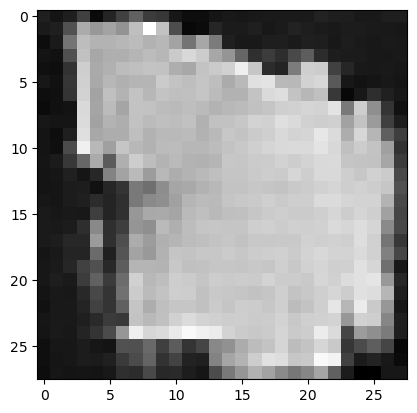

In [ ]:
# sample 64 images
# sampler = sd.Sampler(ddpm_model, DIFFUSER)
sample_fn = partial(sd.sample, ddpm_model, sampler, list(range(0, TIMESTEPS))[::10], eta=0.0, full_process=True)
samples = sample_fn(torch.Size((1, CHANNELS, IMG_SIZE, IMG_SIZE)))

# show a random one
random_index = 0
plt.imshow(samples[-1][random_index].reshape(IMG_SIZE, IMG_SIZE, CHANNELS), cmap="gray")

IndexError: index 50 is out of bounds for dimension 0 with size 1

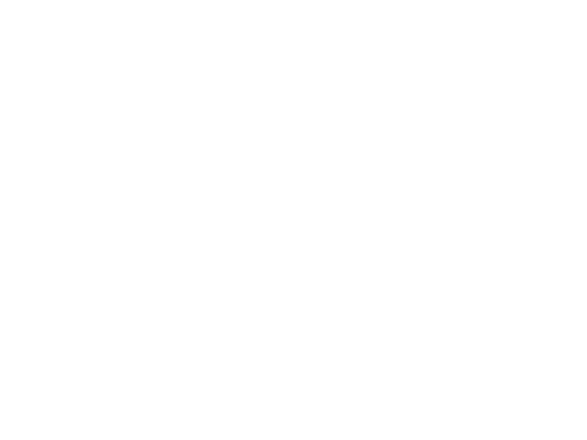

In [30]:
import matplotlib.animation as animation

random_index = 50

fig, ax = plt.subplots(1, 1)
fig.tight_layout()
ims = []
for i in range(TIMESTEPS):
    ax.axis('off')
    im = ax.imshow(samples[i][random_index].reshape(IMG_SIZE, IMG_SIZE, CHANNELS), cmap="gray", animated=True)
    ims.append([im])

animate = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)
animate.save(f'{str(results_folder)}/diffusion.gif')
plt.show()